In [5]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [6]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [7]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (164773325832)>


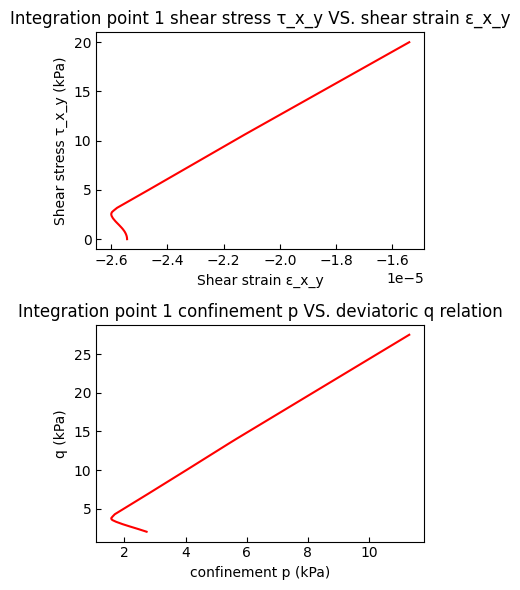

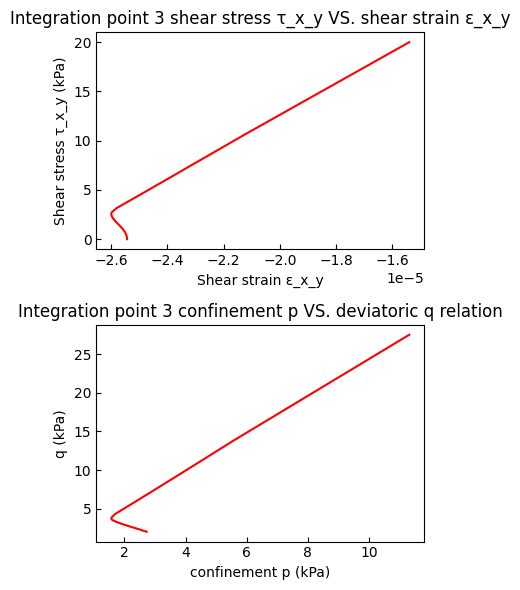

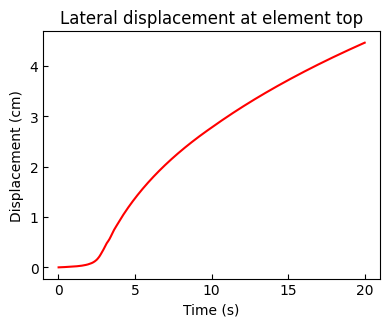

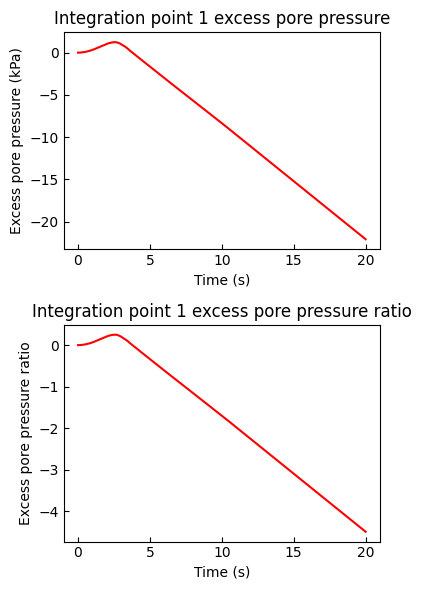

In [8]:
# path: convert_matlab_plots.py

import numpy as np
import matplotlib.pyplot as plt

# Load data
a1 = np.loadtxt('acce.out')
d1 = np.loadtxt('disp.out')
s1 = np.loadtxt('stress1.out')
e1 = np.loadtxt('strain1.out')
s5 = np.loadtxt('stress3.out')
e5 = np.loadtxt('strain3.out')
p1 = np.loadtxt('press1.out')
p3 = np.loadtxt('press3.out')

# Plot settings
fs = [0., 0.2, 4, 6]

# Integration point 1 p-q
po = (s1[:, 1] + s1[:, 2] + s1[:, 3]) / 3
qo = np.sign(s1[:, 3]) * (1 / 3.0) * np.sqrt(
    (s1[:,1] - s1[:,2])**2 + (s1[:,2] - s1[:,3])**2 + (s1[:,1] - s1[:,3])**2 + 6.0 * s1[:,3]**2
)

plt.figure(1, figsize=(fs[2], fs[3]))
plt.clf()

plt.subplot(2, 1, 1)
plt.plot(e1[:, 2], s1[:, 3], 'r')
plt.title('Integration point 1 shear stress τ_x_y VS. shear strain ε_x_y')
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')

plt.subplot(2, 1, 2)
plt.plot(-po, qo, 'r')
plt.title('Integration point 1 confinement p VS. deviatoric q relation')
plt.xlabel('confinement p (kPa)')
plt.ylabel('q (kPa)')
plt.tight_layout()
plt.savefig('SS_PQ1.jpg')

# Integration point 3 p-q
po = (s5[:, 1] + s5[:, 2] + s5[:, 3]) / 3
qo = np.sign(s5[:, 3]) * (1 / 3.0) * np.sqrt(
    (s5[:,1] - s5[:,2])**2 + (s5[:,2] - s5[:,3])**2 + (s5[:,1] - s5[:,3])**2 + 6.0 * s5[:,3]**2
)

plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

plt.subplot(2, 1, 1)
plt.plot(e5[:, 2], s5[:, 3], 'r')
plt.title('Integration point 3 shear stress τ_x_y VS. shear strain ε_x_y')
plt.xlabel('Shear strain ε_x_y')
plt.ylabel('Shear stress τ_x_y (kPa)')

plt.subplot(2, 1, 2)
plt.plot(-po, qo, 'r')
plt.title('Integration point 3 confinement p VS. deviatoric q relation')
plt.xlabel('confinement p (kPa)')
plt.ylabel('q (kPa)')
plt.tight_layout()
plt.savefig('SS_PQ5.jpg')

# Node 3 displacement relative to node 1
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 5] * 100, 'r')
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (cm)')
plt.tight_layout()
plt.savefig('D.jpg')

# Integration point 1 excess pore water pressure
plt.figure(5, figsize=(fs[2], fs[3]))
plt.clf()

plt.subplot(2, 1, 1)
plt.plot(p1[:, 0], -p1[:, 1], 'r')
plt.title('Integration point 1 excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')

plt.subplot(2, 1, 2)
plt.plot(p1[:, 0], p1[:, 2], 'r')
plt.title('Integration point 1 excess pore pressure ratio')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure ratio')

plt.tight_layout()
plt.savefig('EPWP.jpg')